# CELL 1: CÀI ĐẶT THƯ VIỆN & IMPORT

In [1]:
# ------------------------------------------------------------------------------
# CELL 1: CÀI ĐẶT THƯ VIỆN & IMPORT
# ------------------------------------------------------------------------------
!pip install -q transformers datasets evaluate rouge_score sacrebleu accelerate matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.1 MB/s eta 0:00:00


In [2]:
import os
import gc
import torch
import json
import numpy as np
import collections
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import gc
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoModelForSeq2SeqLM,
    DataCollatorWithPadding, DataCollatorForSeq2Seq,
    TrainingArguments, Trainer, Seq2SeqTrainingArguments, Seq2SeqTrainer,
    T5ForConditionalGeneration,
)
import evaluate
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

In [3]:
# ------------------------------------------------------------------------------
# Thiết lập HuggingFace Token (Lấy từ Kaggle Secrets)
# ------------------------------------------------------------------------------
try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    login(token=hf_token)
    print("✅ Đã đăng nhập HuggingFace Hub thành công.")
except Exception as e:
    print("⚠️ Chưa thiết lập Kaggle Secrets cho HF_TOKEN. Vui lòng thiết lập để push model lên Hub.")

✅ Đã đăng nhập HuggingFace Hub thành công.


In [4]:
# Cấu hình chung
# THAY ĐỔI THÀNH REPO DATA CỦA BẠN (Từ Phase 2)
DATA_REPO_ID = "nguyennghia0902/unified-feedback-grading-adb" 
# THAY ĐỔI THÀNH USERNAME CỦA BẠN ĐỂ LƯU MODEL
HF_USERNAME = "nguyennghia0902" 

MODEL_GRADING_NAME = "microsoft/deberta-v3-base"
MODEL_FEEDBACK_NAME = "google/flan-t5-base"

# CELL 2: TẢI DỮ LIỆU TỪ HUGGINGFACE VÀ CHUẨN BỊ

In [5]:
# ==============================================================================
# CELL 2: TẢI DỮ LIỆU TỪ HUGGINGFACE VÀ CHUẨN BỊ
# ==============================================================================
print(f"⏳ Đang tải dữ liệu từ: {DATA_REPO_ID}...")
dataset = load_dataset(DATA_REPO_ID)

print(f"✅ Kích thước tập dữ liệu:")
print(f"  Train: {len(dataset['train'])}")
print(f"  Validation: {len(dataset['validation'])}")
print(f"  Test: {len(dataset['test'])}")

⏳ Đang tải dữ liệu từ: nguyennghia0902/unified-feedback-grading-adb...


README.md:   0%|          | 0.00/874 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/72.0M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.80M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.88M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/22603 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2752 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2775 [00:00<?, ? examples/s]

✅ Kích thước tập dữ liệu:
  Train: 22603
  Validation: 2752
  Test: 2775


In [6]:
def plot_training_history(trainer_state, title, metric_name="loss", save_path=None, use_epoch=False):
    history = pd.DataFrame(trainer_state.log_history)
    plt.figure(figsize=(10, 6))
    
    # Chọn cột X: step hoặc epoch
    x_col = 'epoch' if use_epoch and 'epoch' in history.columns else 'step'
    
    if 'loss' in history.columns:
        train_points = history.dropna(subset=['loss'])
        plt.plot(train_points[x_col], train_points['loss'], 
                 label='Training Loss', color='blue', alpha=0.6)
    
    eval_col = f'eval_{metric_name}'
    if eval_col in history.columns:
        eval_points = history.dropna(subset=[eval_col])
        plt.plot(eval_points[x_col], eval_points[eval_col], 
                 label=f'Validation {metric_name.capitalize()}', 
                 color='red', marker='o')
        
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch' if use_epoch else 'Training Steps', fontsize=12)
    plt.ylabel(metric_name.capitalize(), fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"  ✅ Đã lưu biểu đồ tại: {save_path}")
    plt.show()

def plot_train_val_history(trainer_state, title, metric_name="loss", save_path=None):
    history = pd.DataFrame(trainer_state.log_history)
    plt.figure(figsize=(10, 6))
    
    # X-axis: epoch nếu có, fallback sang step
    x_col = 'epoch' if 'epoch' in history.columns else 'step'
    
    if metric_name == "loss":
        # Training loss: chỉ lấy cột 'loss'
        if 'loss' in history.columns:
            train_loss = history.dropna(subset=['loss'])
            plt.plot(train_loss[x_col], train_loss['loss'], 
                     label='Training Loss', color='blue', alpha=0.8)
        
        # Validation loss: chỉ lấy cột 'eval_loss'
        if 'eval_loss' in history.columns:
            val_loss = history.dropna(subset=['eval_loss'])
            plt.plot(val_loss[x_col], val_loss['eval_loss'], 
                     label='Validation Loss', color='red', alpha=0.8)
        
        plt.ylabel("Loss", fontsize=12)
    
    else:
        # Training metric: nếu trainer log ra (thường ít có)
        if metric_name in history.columns:
            train_metric = history.dropna(subset=[metric_name])
            plt.plot(train_metric[x_col], train_metric[metric_name], 
                     label=f'Training {metric_name.capitalize()}', color='green', alpha=0.8)
        
        # Validation metric: eval_xxx
        eval_col = f'eval_{metric_name}'
        if eval_col in history.columns:
            val_metric = history.dropna(subset=[eval_col])
            plt.plot(val_metric[x_col], val_metric[eval_col], 
                     label=f'Validation {metric_name.capitalize()}', color='orange', alpha=0.8)
        
        plt.ylabel(metric_name.capitalize(), fontsize=12)
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch' if x_col == 'epoch' else 'Training Steps', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"  ✅ Đã lưu biểu đồ tại: {save_path}")
    plt.show()


# CELL 3: HUẤN LUYỆN MÔ HÌNH AUTO GRADING (DEBERTA)

In [7]:
# ── Dọn dẹp GPU ──────────────────────────────────────────────────────
torch.cuda.empty_cache()
gc.collect()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

grading_tokenizer = AutoTokenizer.from_pretrained(MODEL_GRADING_NAME)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

## 1. Hàm Tiền xử lý cho cho DeBERTa-Grading

In [8]:
# Tiền xử lý: Ép điểm số về 3 nhãn (0, 1, 2)
SCORE_TO_LABEL = {0.0: 0, 0.5: 1, 1.0: 2}
def preprocess_grading_classification(examples):
    context = [f"Question: {q} [SEP] Reference: {r}"
               for q, r in zip(examples["question"], examples["reference_answer"])]
    
    model_inputs = grading_tokenizer(
        context,
        examples["student_answer"],
        max_length=512,
        padding="max_length",
        truncation=True,
    )
    
    labels = []
    for score in examples["score"]:
        try:
            s = float(score)
            if np.isnan(s): s = 0.0
        except:
            s = 0.0
        # Map trực tiếp — không dùng ngưỡng thủ công
        label = SCORE_TO_LABEL.get(round(s, 1), 0)
        labels.append(label)
    
    model_inputs["labels"] = labels
    return model_inputs


print("⏳ Đang Tokenize dữ liệu cho Grading...")
tokenized_grading_datasets = dataset.map(preprocess_grading_classification, batched=True, remove_columns=dataset['train'].column_names)

⏳ Đang Tokenize dữ liệu cho Grading...


Map:   0%|          | 0/22603 [00:00<?, ? examples/s]

Map:   0%|          | 0/2752 [00:00<?, ? examples/s]

Map:   0%|          | 0/2775 [00:00<?, ? examples/s]

## 2. Định nghĩa Model và Metric cho DeBERTa-Grading

In [9]:
# ── Tính class weights bằng sklearn (chuẩn hơn) ──────────────────────
train_labels_np = np.array(tokenized_grading_datasets["train"]["labels"])
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_labels_np,
)
print(f"Class weights → INCORRECT: {class_weights_np[0]:.3f} | "
      f"PARTIAL: {class_weights_np[1]:.3f} | "
      f"CORRECT: {class_weights_np[2]:.3f}")

# ── Load model với torch_dtype=torch.float32 (FIX chính) ─────────────
id2label = {0: "INCORRECT", 1: "PARTIAL", 2: "CORRECT"}
label2id = {"INCORRECT": 0, "PARTIAL": 1, "CORRECT": 2}

grading_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_GRADING_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.float32,      # ← FIX: tắt hoàn toàn mixed precision
    ignore_mismatched_sizes=True,
)

# ── compute_metrics ───────────────────────────────────────────────────
def compute_metrics_classification(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    f1_per = f1_score(labels, preds, average=None, zero_division=0)
    print(f"[Metrics] Accuracy: {accuracy_score(labels, preds):.4f} | "
          f"F1-Macro: {f1_score(labels, preds, average='macro', zero_division=0):.4f}")
    print(f"F1 per class → INCORRECT: {f1_per[0]:.4f} | "
          f"PARTIAL: {f1_per[1]:.4f} | CORRECT: {f1_per[2]:.4f}")
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1_macro":  f1_score(labels, preds, average="macro", zero_division=0),
        "f1_incorrect": f1_per[0],
        "f1_partial":   f1_per[1],
        "f1_correct":   f1_per[2],
    }

Class weights → INCORRECT: 2.627 | PARTIAL: 1.102 | CORRECT: 0.584


`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight        

## 3. Cấu hình TrainArguments cho DeBERTa-Grading

In [10]:
grading_output_dir = "./deberta-grading-results"
grading_training_args = TrainingArguments(
    output_dir=grading_output_dir,
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,      # effective batch = 32
    num_train_epochs=7,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=False,                          # ← TẮT
    bf16=False,                          # ← TẮT tường minh
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=100,
    push_to_hub=True,
    hub_model_id=f"{HF_USERNAME}/deberta-auto-grading-newfinal",
    report_to="none",
)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [11]:
# ── WeightedTrainer (truyền weights qua __init__) ─────────────────────
class WeightedTrainer(Trainer):
    def __init__(self, class_weights_np, **kwargs):
        super().__init__(**kwargs)
        self._cw_np = class_weights_np          # lưu numpy array

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits                # float32 vì model load float32
        weights = torch.tensor(
            self._cw_np, dtype=torch.float32, device=logits.device
        )
        loss = nn.CrossEntropyLoss(weight=weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

## 4. Huấn luyện Model cho DeBERTa-Grading

In [12]:
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM used  : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

# Nếu VRAM còn <10GB thì clear cache trước
torch.cuda.empty_cache()
gc.collect()

print("✅ Cache cleared")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GPU: Tesla T4
VRAM total : 15.6 GB
VRAM used  : 0.00 GB
VRAM free  : 15.64 GB
✅ Cache cleared


In [13]:
grading_trainer = WeightedTrainer(
    class_weights_np=class_weights_np,
    model=grading_model,
    args=grading_training_args,
    train_dataset=tokenized_grading_datasets["train"],
    eval_dataset=tokenized_grading_datasets["validation"],
    processing_class=grading_tokenizer,
    compute_metrics=compute_metrics_classification,
    data_collator=DataCollatorWithPadding(tokenizer=grading_tokenizer),
)
print("Bắt đầu Training DeBERTa Auto Grading...")
train_output = grading_trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Bắt đầu Training DeBERTa Auto Grading...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Incorrect,F1 Partial,F1 Correct
1,1.752985,0.560087,0.740552,0.717270,0.690083,0.649030,0.812698
2,1.000929,0.500962,0.760901,0.749066,0.741474,0.686837,0.818886
3,0.723276,0.528246,0.785247,0.758515,0.743344,0.676396,0.855805
4,0.574448,0.518123,0.789608,0.769982,0.760000,0.699394,0.850551
5,0.466128,0.618019,0.791788,0.778951,0.771727,0.718531,0.846595
6,0.388060,0.615994,0.805233,0.789794,0.781473,0.728090,0.859820
7,0.319446,0.670627,0.805233,0.788632,0.778429,0.727169,0.860297


[Metrics] Accuracy: 0.7406 | F1-Macro: 0.7173
F1 per class → INCORRECT: 0.6901 | PARTIAL: 0.6490 | CORRECT: 0.8127


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[Metrics] Accuracy: 0.8052 | F1-Macro: 0.7898
F1 per class → INCORRECT: 0.7815 | PARTIAL: 0.7281 | CORRECT: 0.8598


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[Metrics] Accuracy: 0.8052 | F1-Macro: 0.7886
F1 per class → INCORRECT: 0.7784 | PARTIAL: 0.7272 | CORRECT: 0.8603


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

In [14]:
train_dict = {
    "global_step": train_output.global_step,
    "training_loss": train_output.training_loss,
    "metrics": train_output.metrics
}
print(json.dumps(train_dict, indent=2))

{
  "global_step": 2478,
  "training_loss": 0.7464675256761454,
  "metrics": {
    "train_runtime": 16432.0904,
    "train_samples_per_second": 9.629,
    "train_steps_per_second": 0.151,
    "total_flos": 4.163081464668672e+16,
    "train_loss": 0.7464675256761454,
    "epoch": 7.0
  }
}


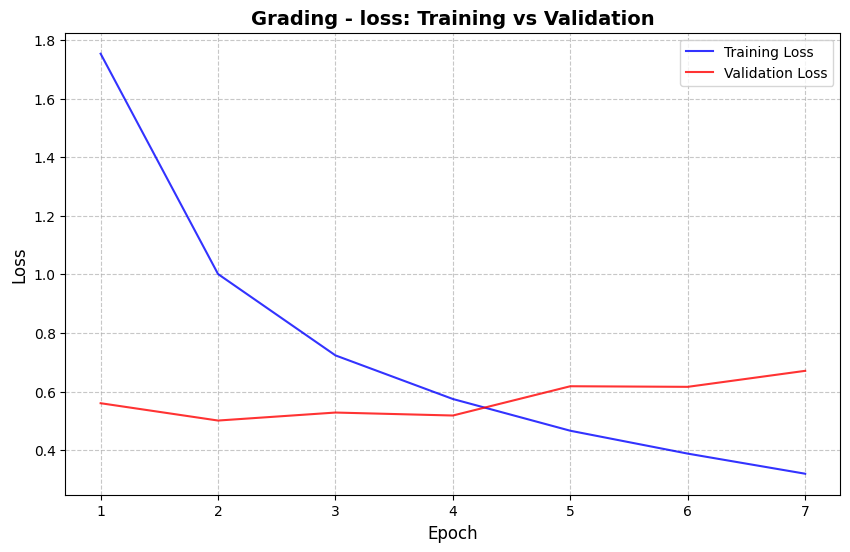

In [15]:
plot_train_val_history(grading_trainer.state, "Grading - loss: Training vs Validation", metric_name="loss")

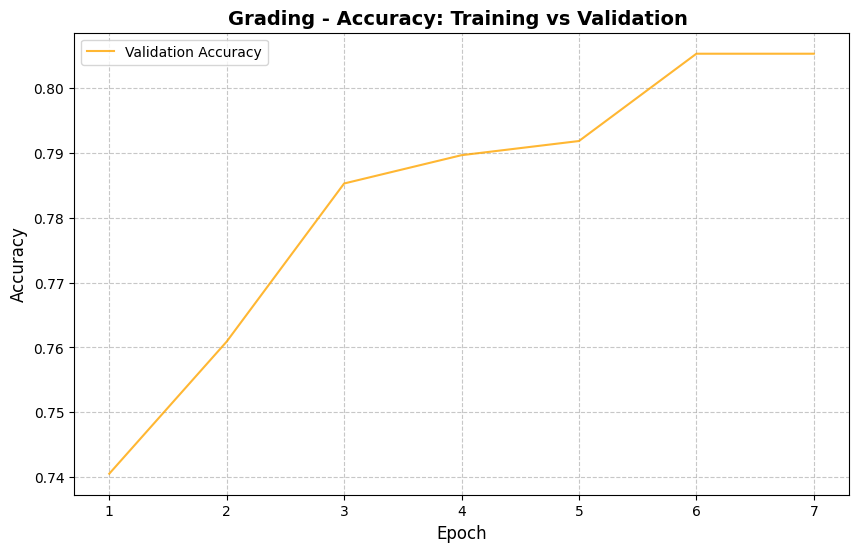

In [16]:
plot_train_val_history(grading_trainer.state, "Grading - Accuracy: Training vs Validation ", metric_name="accuracy")

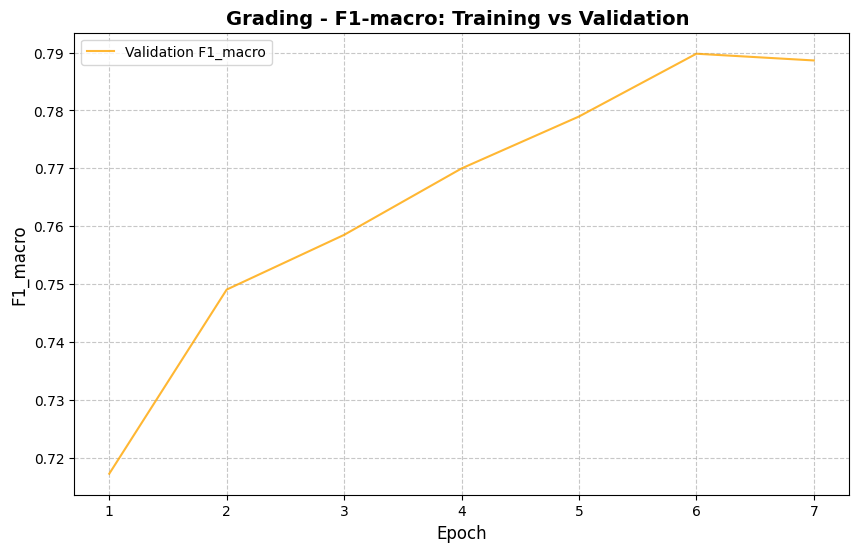

In [17]:
plot_train_val_history(grading_trainer.state, "Grading - F1-macro: Training vs Validation ", metric_name="f1_macro")

## 5. Đánh giá và Trực quan hóa kết quả Grading

In [18]:
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM used  : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

# Nếu VRAM còn <10GB thì clear cache trước
torch.cuda.empty_cache()
gc.collect()

print("✅ Cache cleared")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GPU: Tesla T4
VRAM total : 15.6 GB
VRAM used  : 2.23 GB
VRAM free  : 13.40 GB
✅ Cache cleared


In [19]:
print("\n📊 Đánh giá trên tập Test (Grading):")
grading_test_results = grading_trainer.evaluate(tokenized_grading_datasets["test"])
print(json.dumps(grading_test_results, indent=2))


📊 Đánh giá trên tập Test (Grading):


[Metrics] Accuracy: 0.8292 | F1-Macro: 0.8088
F1 per class → INCORRECT: 0.8100 | PARTIAL: 0.7366 | CORRECT: 0.8797
{
  "eval_loss": 0.5761058330535889,
  "eval_accuracy": 0.8291891891891892,
  "eval_f1_macro": 0.8087889548302424,
  "eval_f1_incorrect": 0.8100147275405007,
  "eval_f1_partial": 0.7366482504604052,
  "eval_f1_correct": 0.8797038864898211,
  "eval_runtime": 74.974,
  "eval_samples_per_second": 37.013,
  "eval_steps_per_second": 0.587,
  "epoch": 7.0
}


  ✅ Đã lưu biểu đồ tại: grading_accuracy.png


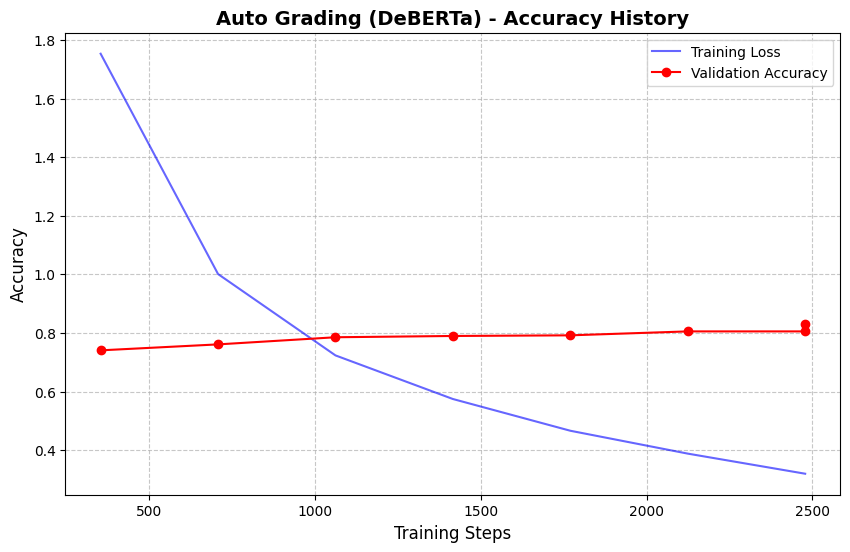

In [20]:
plot_training_history(grading_trainer.state, "Auto Grading (DeBERTa) - Accuracy History", metric_name="accuracy", save_path="grading_accuracy.png")


  ✅ Đã lưu biểu đồ tại: grading_loss.png


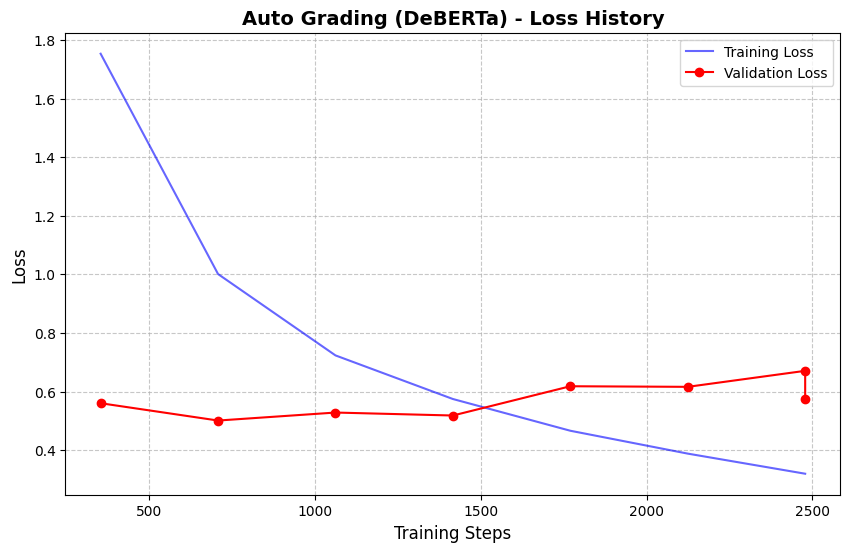

In [21]:
plot_training_history(grading_trainer.state, "Auto Grading (DeBERTa) - Loss History", metric_name="loss", save_path="grading_loss.png")

  ✅ Đã lưu biểu đồ tại: grading_f1_macro.png


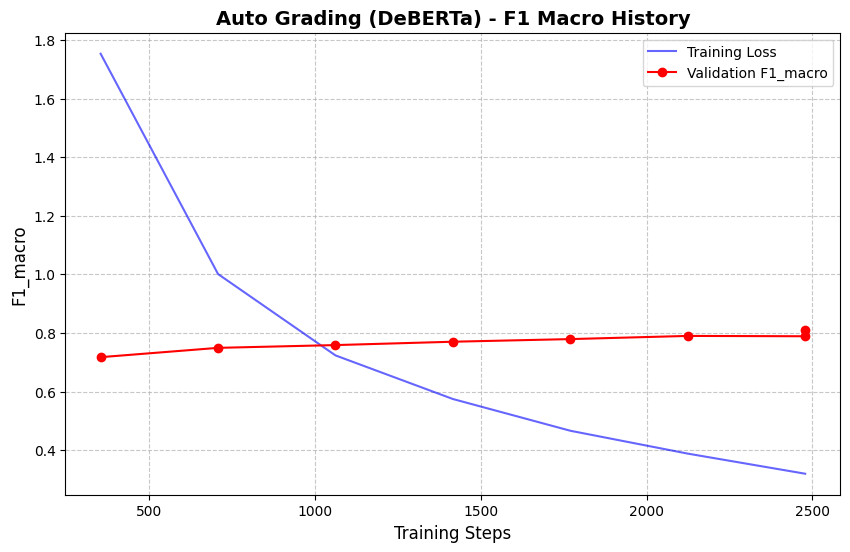

In [22]:

plot_training_history(grading_trainer.state, "Auto Grading (DeBERTa) - F1 Macro History", metric_name="f1_macro", save_path="grading_f1_macro.png")

In [23]:
print("\n☁️ Pushing Grading Model to HuggingFace Hub...")
try:
    grading_trainer.push_to_hub()
except Exception as e:
    print(f"Bỏ qua lỗi push hub: {e}")


☁️ Pushing Grading Model to HuggingFace Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

# CELL 4: CHUẨN BỊ DỮ LIỆU ĐẦU VÀO CHO FEEDBACK GENERATION

In [24]:
# ==============================================================================
# CELL 4: CHUẨN BỊ DỮ LIỆU ĐẦU VÀO CHO FEEDBACK GENERATION
# ==============================================================================
print("\n" + "="*50)
print("⚙️ CHUẨN BỊ DỮ LIỆU CHO FEEDBACK MODEL")
print("="*50)

# Lọc các mẫu CÓ feedback để huấn luyện T5
fb_dataset = dataset.filter(
    lambda x: x["feedback"] is not None and len(str(x["feedback"]).strip()) > 5
)

# Thêm cột predicted_score = score thật (không cần chạy model Grading trước)
def add_true_score(example):
    try:
        s = float(example["score"])
        if np.isnan(s):
            s = 0.0
    except:
        s = 0.0
    example["predicted_score"] = s
    return example

fb_dataset = fb_dataset.map(add_true_score)

print(f"\n✅ Số lượng mẫu DÙNG ĐỂ TRAIN FEEDBACK:")
print(f"  Train:      {len(fb_dataset['train'])}")
print(f"  Validation: {len(fb_dataset['validation'])}")
print(f"\n📊 Score distribution (Train):")

score_counts = collections.Counter(fb_dataset["train"]["predicted_score"])
for k in sorted(score_counts):
    pct = score_counts[k] / len(fb_dataset["train"]) * 100
    print(f"  {k:.1f} → {score_counts[k]:5d} mẫu ({pct:.1f}%)")


⚙️ CHUẨN BỊ DỮ LIỆU CHO FEEDBACK MODEL


Filter:   0%|          | 0/22603 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2752 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2775 [00:00<?, ? examples/s]

Map:   0%|          | 0/7881 [00:00<?, ? examples/s]

Map:   0%|          | 0/1090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1029 [00:00<?, ? examples/s]


✅ Số lượng mẫu DÙNG ĐỂ TRAIN FEEDBACK:
  Train:      7881
  Validation: 1090

📊 Score distribution (Train):
  0.0 →   668 mẫu (8.5%)
  0.5 →  3205 mẫu (40.7%)
  1.0 →  4008 mẫu (50.9%)


# CELL 5: HUẤN LUYỆN MÔ HÌNH FEEDBACK GENERATION (FLAN-T5)

In [25]:
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM used  : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

# Nếu VRAM còn <10GB thì clear cache trước
torch.cuda.empty_cache()
gc.collect()

print("✅ Cache cleared")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GPU: Tesla T4
VRAM total : 15.6 GB
VRAM used  : 2.23 GB
VRAM free  : 13.40 GB
✅ Cache cleared


In [26]:
# ==============================================================================
# CELL 5: HUẤN LUYỆN MÔ HÌNH FEEDBACK GENERATION (T5)
# ==============================================================================
print("\n" + "="*50)
print("🚀 BẮT ĐẦU HUẤN LUYỆN FEEDBACK GENERATION MODEL")
print("="*50)

MODEL_T5_NAME = MODEL_FEEDBACK_NAME 
MAX_INPUT_LEN = 512
MAX_OUTPUT_LEN = 256

t5_tokenizer = AutoTokenizer.from_pretrained(MODEL_T5_NAME, use_fast=True)
t5_model = T5ForConditionalGeneration.from_pretrained(MODEL_T5_NAME)


🚀 BẮT ĐẦU HUẤN LUYỆN FEEDBACK GENERATION MODEL


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

## 1. Hàm Tiền xử lý cho cho T5-FbGen

In [27]:
def preprocess_t5(batch):
    SCORE_LABEL_MAP = {0.0: "incorrect", 0.5: "partially correct", 1.0: "correct"}

    input_texts = [
        f"Generate educational feedback based on the following information:\n"
        f"Question: {q}\n"
        f"Ideal Answer: {r}\n"
        f"Student Response: {s}\n"
        f"Assigned Score: {float(score):.1f}/1.0 ({SCORE_LABEL_MAP.get(float(score), 'unknown')})\n"
        f"Feedback:"
        for q, r, s, score in zip(
            batch['question'],
            batch['reference_answer'],
            batch['student_answer'],
            batch['predicted_score']
        )
    ]
    target_texts = batch['feedback']

    model_inputs = t5_tokenizer(
        input_texts,
        max_length=MAX_INPUT_LEN,
        truncation=True,
        padding="max_length"
    )

    labels = t5_tokenizer(
        text_target=target_texts,
        max_length=MAX_OUTPUT_LEN,
        truncation=True,
        padding="max_length"
    )

    label_ids = [
        [tok if tok != t5_tokenizer.pad_token_id else -100 for tok in seq]
        for seq in labels["input_ids"]
    ]
    model_inputs["labels"] = label_ids
    return model_inputs

print("⏳ Đang Tokenize dữ liệu cho T5 Generation...")
tokenized_t5_datasets = fb_dataset.map(preprocess_t5, batched=True, remove_columns=fb_dataset['train'].column_names)

⏳ Đang Tokenize dữ liệu cho T5 Generation...


Map:   0%|          | 0/7881 [00:00<?, ? examples/s]

Map:   0%|          | 0/1090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1029 [00:00<?, ? examples/s]

## 2. Định nghĩa Model và Metric cho T5-FbGen

In [28]:
rouge = evaluate.load("rouge")

def compute_metrics_t5(eval_pred):
    preds, labels = eval_pred

    # Fix: thay -100 bằng pad_token_id trước khi decode
    preds  = np.where(preds  != -100, preds,  t5_tokenizer.pad_token_id)
    labels = np.where(labels != -100, labels, t5_tokenizer.pad_token_id)

    # Clip tránh overflow ngoài vocab size
    vocab_size = t5_tokenizer.vocab_size
    preds  = np.clip(preds,  0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)

    decoded_preds  = t5_tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = t5_tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )
    return {k: round(v * 100, 4) for k, v in result.items()}

## 3. Cấu hình TrainArguments cho T5-FbGen

In [29]:
t5_output_dir = "./t5-feedback-results"
t5_training_args = Seq2SeqTrainingArguments(
    output_dir=t5_output_dir,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=4,       # effective batch = 32
    num_train_epochs=7,
    warmup_steps=200,
    weight_decay=0.01,
    fp16=False,                           # ← TẮT
    bf16=False,                           # ← TẮT tường minh
    gradient_checkpointing=True,
    optim="adafactor",                    # tiết kiệm VRAM hơn Adam
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    predict_with_generate=True,
    generation_max_length=256,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=100,
    push_to_hub=True,
    hub_model_id=f"{HF_USERNAME}/t5-feedback-generator-newfinal",
    report_to="none",
)

## 4. Huấn luyện Model cho T5-FbGen

In [30]:
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM used  : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

# Nếu VRAM còn <10GB thì clear cache trước
torch.cuda.empty_cache()
gc.collect()

print("✅ Cache cleared")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GPU: Tesla T4
VRAM total : 15.6 GB
VRAM used  : 2.23 GB
VRAM free  : 13.40 GB
✅ Cache cleared


In [31]:
t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_training_args,
    train_dataset=tokenized_t5_datasets["train"],
    eval_dataset=tokenized_t5_datasets["validation"],
    processing_class=t5_tokenizer,
    data_collator=DataCollatorForSeq2Seq(t5_tokenizer, model=t5_model),
    compute_metrics=compute_metrics_t5,
)

print("Bắt đầu Training T5 Feedback Generator...")
train_output = t5_trainer.train()

Bắt đầu Training T5 Feedback Generator...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,67.922678,6.566434,12.251100,1.691800,12.038100,12.039300
2,49.762191,4.258353,45.189600,24.725800,37.039300,36.998200
3,32.093203,2.480298,42.006300,22.781300,33.304900,33.277400
4,19.708693,1.475339,47.361900,29.511100,38.675200,38.592100
5,12.670759,1.004104,55.667900,39.880400,48.780600,48.733900
6,9.337164,0.812964,58.071100,41.520800,50.804800,50.774300
7,8.045456,0.758686,59.980800,43.989500,52.642600,52.647600


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


In [32]:
train_dict = {
    "global_step": train_output.global_step,
    "training_loss": train_output.training_loss,
    "metrics": train_output.metrics
}

print(json.dumps(train_dict, indent=2))

{
  "global_step": 868,
  "training_loss": 28.50573484359249,
  "metrics": {
    "train_runtime": 13929.5199,
    "train_samples_per_second": 3.96,
    "train_steps_per_second": 0.062,
    "total_flos": 3.777600886249882e+16,
    "train_loss": 28.50573484359249,
    "epoch": 7.0
  }
}


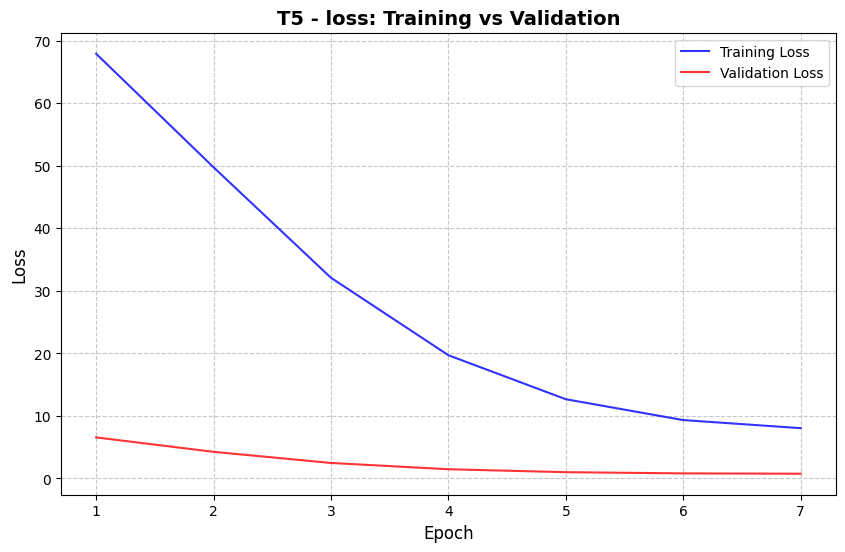

In [33]:
plot_train_val_history(t5_trainer.state, "T5 - loss: Training vs Validation", metric_name="loss")

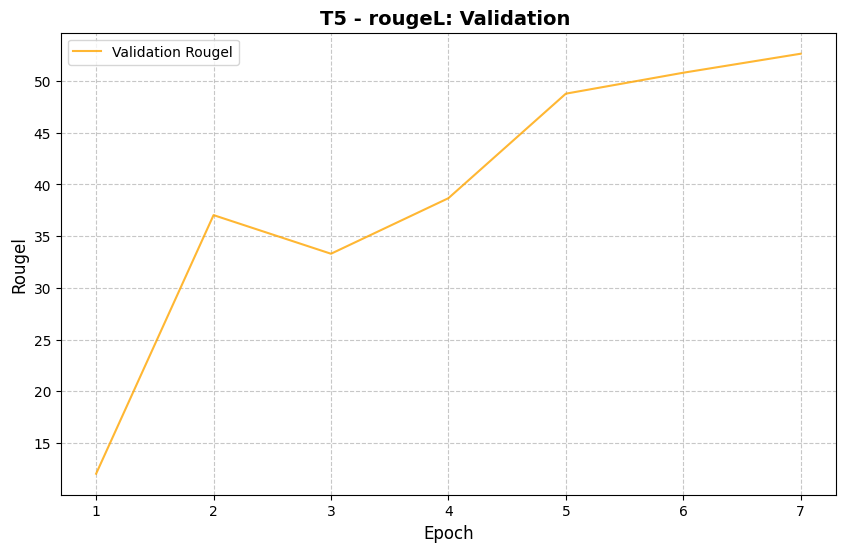

In [34]:
plot_train_val_history(t5_trainer.state, "T5 - rougeL: Validation ", metric_name="rougeL")

## 5. Đánh giá và Trực quan hóa kết quả cho T5-FbGen

In [35]:
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM used  : {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
print(f"VRAM free  : {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

# Nếu VRAM còn <10GB thì clear cache trước
torch.cuda.empty_cache()
gc.collect()

print("✅ Cache cleared")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

GPU: Tesla T4
VRAM total : 15.6 GB
VRAM used  : 3.23 GB
VRAM free  : 12.40 GB
✅ Cache cleared


In [36]:
print("\n📊 Đánh giá trên tập Test (Feedback):")
t5_test_results = t5_trainer.evaluate(tokenized_t5_datasets["test"])


📊 Đánh giá trên tập Test (Feedback):


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [37]:
print(json.dumps(t5_test_results, indent=2))

{
  "eval_loss": 0.7527880072593689,
  "eval_rouge1": 60.1665,
  "eval_rouge2": 44.1767,
  "eval_rougeL": 52.7167,
  "eval_rougeLsum": 52.7375,
  "eval_runtime": 607.5996,
  "eval_samples_per_second": 1.694,
  "eval_steps_per_second": 0.054,
  "epoch": 7.0
}


  ✅ Đã lưu biểu đồ tại: t5_feedback_rougeL.png


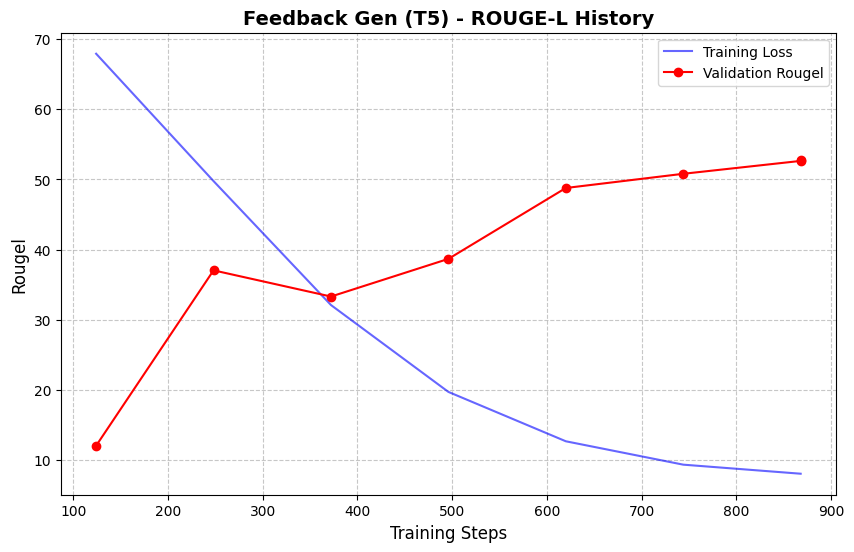

In [38]:
plot_training_history(t5_trainer.state, "Feedback Gen (T5) - ROUGE-L History", metric_name="rougeL", save_path="t5_feedback_rougeL.png")

  ✅ Đã lưu biểu đồ tại: t5_feedback_loss.png


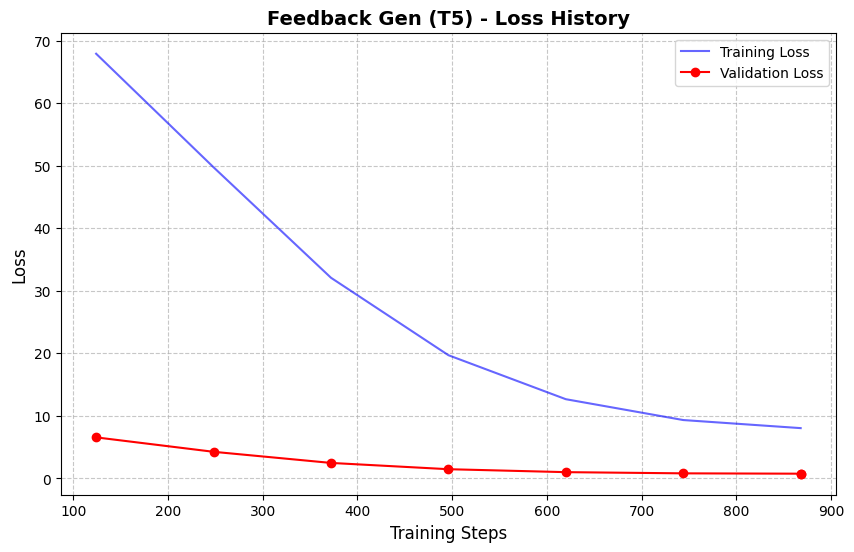

In [39]:
plot_training_history(t5_trainer.state, "Feedback Gen (T5) - Loss History", metric_name="loss", save_path="t5_feedback_loss.png")

In [40]:
print("\n☁️ Pushing T5 Feedback Model to HuggingFace Hub...")
try:
    t5_trainer.push_to_hub()
except Exception as e:
    print(f"Bỏ qua lỗi push hub: {e}")


☁️ Pushing T5 Feedback Model to HuggingFace Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [41]:
print("🎉 HOÀN TẤT PHASE 3! Cả hai mô hình đã sẵn sàng để bọc Docker và Streamlit ở Phase 4.")

🎉 HOÀN TẤT PHASE 3! Cả hai mô hình đã sẵn sàng để bọc Docker và Streamlit ở Phase 4.
